# Lab 9: Feature Reduction

## Part 1: Breast Cancer Example

In this example, we will continue with the breast cancer dataset example in the Introduction to PCA.ipynb file, to see if using PCA can improve the results

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import warnings
warnings.filterwarnings(action='ignore')

The first step is to load the dataset and split it into training and testing sets (testing should be 10% of the data).

In [3]:
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer()

In [4]:
from sklearn.model_selection import train_test_split

# split the data in training and test set
X_train, X_test, y_train, y_test = train_test_split(cancer.data, cancer.target, stratify=cancer.target, test_size=0.1, random_state=0)

Next, we can implement the PCA. Note that we should use scaling for this dataset, so let's try PCA with whitening, to represent 95% of the variance in the data:

In [5]:
from sklearn.decomposition import PCA

pca = PCA(0.95, whiten=True).fit(X_train)
pca.n_components_

1

Why do we only need one component to represent 95% of the variance? This doesn't match the results from the previous example. Let's try plotting the explained variance ratio:

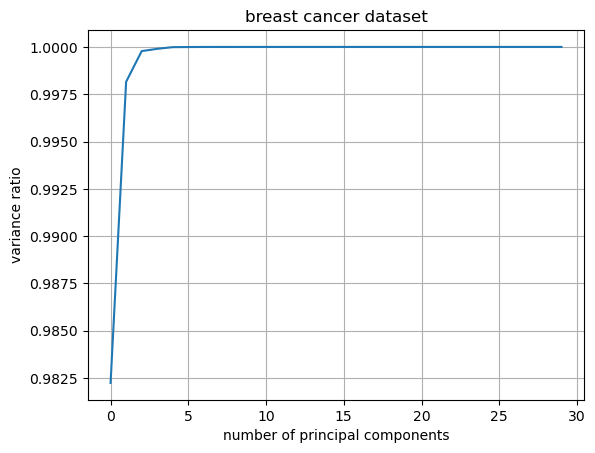

In [6]:
pca_all = PCA()
pca_all.fit(X_train)
plt.plot(np.cumsum(pca_all.explained_variance_ratio_))
plt.xlabel('number of principal components')
plt.ylabel('variance ratio')
plt.title('breast cancer dataset')
plt.grid(True)

Remember from the previous examples that whitening has the same effect as applying a StandardScaler **after** PCA transformation. In this case, we need to apply the scaler **before** the PCA transformation to properly select the number of components.

In [7]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
from sklearn.decomposition import PCA

pca = PCA(0.95).fit(X_train_scaled)
pca.n_components_

10

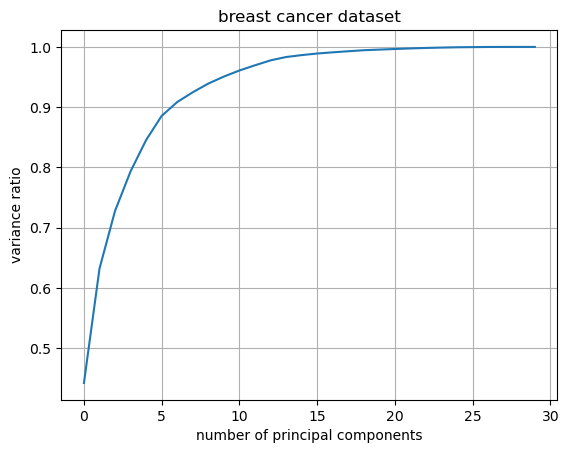

In [9]:
pca_all = PCA()
pca_all.fit(X_train_scaled)
plt.plot(np.cumsum(pca_all.explained_variance_ratio_))
plt.xlabel('number of principal components')
plt.ylabel('variance ratio')
plt.title('breast cancer dataset')
plt.grid(True)

Now we can transform the data and implement our selected machine learning model:

In [10]:
X_train_pca = pca.transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

In [11]:
from sklearn.svm import SVC

svc = SVC()

In [12]:
from sklearn.model_selection import GridSearchCV

param_grid = {'C': [0.01, 0.1, 1.0, 10.0],
              'gamma': [0.01, 0.1, 1.0, 10.0]}

grid = GridSearchCV(svc, param_grid, cv=5)

grid.fit(X_train_pca, y_train)

print("Best params:\n{}\n".format(grid.best_params_))
print("Best cross-validation score: {:.2f}".format(grid.best_score_))
print("Test-set score: {:.2f}".format(grid.score(X_test_pca, y_test)))

Best params:
{'C': 10.0, 'gamma': 0.01}

Best cross-validation score: 0.98
Test-set score: 0.98


## Part 2: Spam Dataset Practice

In this example, we will go back to the spam dataset from previous assignments to see if we can improve the results using PCA.

In [13]:
# TO DO: Import spam dataset from yellowbrick library
from yellowbrick.datasets import load_spam

X, y = load_spam()

X.shape

(4600, 57)

In [14]:
# TO DO: Split 10% of the data for the testing set

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, stratify=y, random_state=0)

In this case, do we need to scale the data?

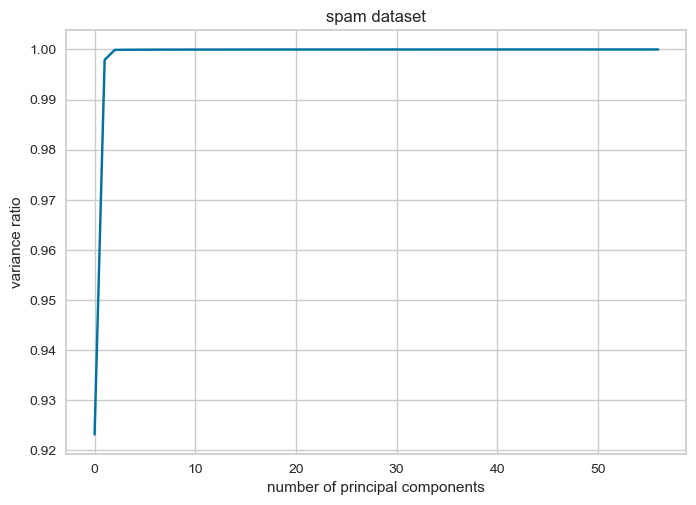

In [15]:
# TO DO: Plot explained variance with unscaled data
pca_all = PCA()
pca_all.fit(X_train)
plt.plot(np.cumsum(pca_all.explained_variance_ratio_))
plt.xlabel('number of principal components')
plt.ylabel('variance ratio')
plt.title('spam dataset')
plt.grid(True)

In [16]:
# TO DO: Scale data (if needed)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

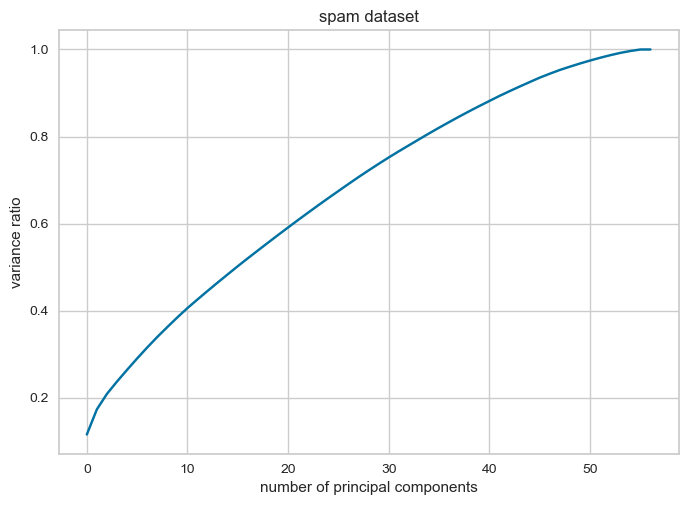

In [17]:
# TO DO: Plot explained variance with scaled data (if needed)
pca_all = PCA()
pca_all.fit(X_train_scaled)
plt.plot(np.cumsum(pca_all.explained_variance_ratio_))
plt.xlabel('number of principal components')
plt.ylabel('variance ratio')
plt.title('spam dataset')
plt.grid(True)

How many components do we need to explain ~95% of the variance?

In [18]:
# TO DO: Implement PCA - keep enough components to explain 95% of the variance
pca = PCA(0.95).fit(X_train_scaled)
pca.n_components_

48

In [19]:
# TO DO: Transform training and testing data
X_train_pca = pca.transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

In [20]:
# TO DO: Implement Grid Search with Random Forest (create a relevant parameter grid)
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=0)

param_grid = {'max_depth': [3, 5, 7, 9, 11]}

grid = GridSearchCV(rf, param_grid, cv=5)

grid.fit(X_train_pca, y_train)

print("Best params:\n{}\n".format(grid.best_params_))
print("Best cross-validation score: {:.2f}".format(grid.best_score_))
print("Test-set score: {:.2f}".format(grid.score(X_test_pca, y_test)))

Best params:
{'max_depth': 11}

Best cross-validation score: 0.93
Test-set score: 0.93


In this case, was it worthwhile to use PCA?